In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD THE DATA
# Colab uses the filename exactly as you uploaded it
print("Loading data... please wait.")
df = pd.read_csv('../data/raw/listings.csv')

# 2. SELECT IMPORTANT COLUMNS (The essentials)
cols = ['neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
        'room_type', 'accommodates', 'bedrooms', 'beds', 'amenities', 'price']
df_clean = df[cols].copy()

# 3. CLEAN THE PRICE (Turning text like "$100.00" into 100)
df_clean['price'] = df_clean['price'].str.replace('$', '').str.replace(',', '').astype(float)

# 4. REMOVE OUTLIERS (Keeping prices between 50 and 5000 Brazilian Reais)
df_clean = df_clean[(df_clean['price'] >= 50) & (df_clean['price'] <= 5000)]

# 5. FIX MISSING VALUES
df_clean['bedrooms'] = df_clean['bedrooms'].fillna(1)
df_clean['beds'] = df_clean['beds'].fillna(1)

print("Data is clean! Here is the top 5 rows:")
df_clean.head()

Loading data... please wait.
Data is clean! Here is the top 5 rows:


,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price
0,Copacabana,-22.96599,-43.17940,Entire condo,Entire home/apt,5,2.0,2.0,"[""Private entrance"", ""Hot water"", ""Wifi"", ""Sto...",565.00
1,Copacabana,-22.97649,-43.19122,Entire rental unit,Entire home/apt,3,1.0,2.0,"[""Dining table"", ""Hammock"", ""Hot water"", ""Stov...",542.50
2,Copacabana,-22.98107,-43.19136,Entire loft,Entire home/apt,2,1.0,1.0,"[""Hot water"", ""Beach view"", ""Heating"", ""Wifi"",...",369.00
3,Ipanema,-22.98591,-43.20302,Entire rental unit,Entire home/apt,13,6.0,7.0,"[""Private entrance"", ""Pack \u2019n play/Travel...",4025.00
4,Copacabana,-22.96574,-43.17514,Entire rental unit,Entire home/apt,9,4.0,5.0,"[""Dining table"", ""Pets allowed"", ""Hot water"", ...",1314.67


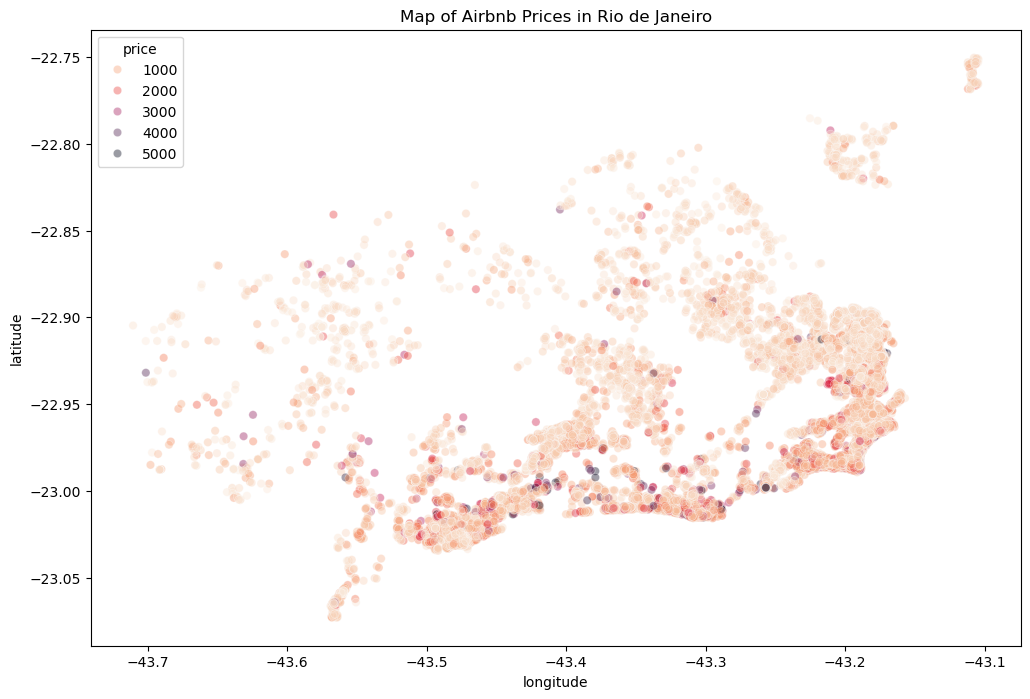

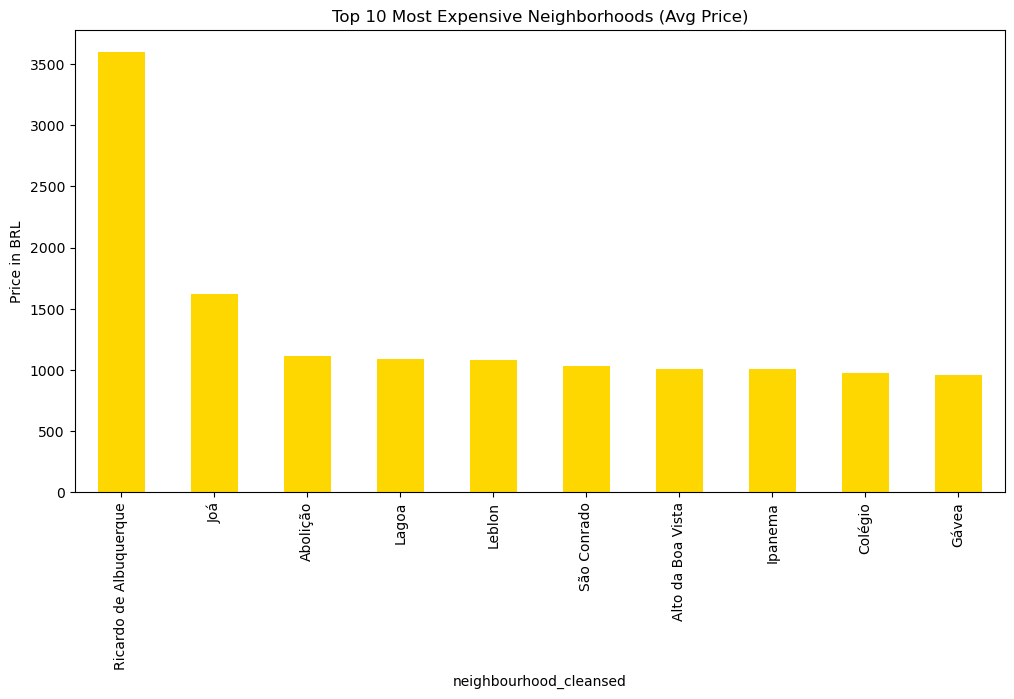

In [2]:
# GRAPH 1: Price Map of Rio
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_clean, x='longitude', y='latitude', hue='price', palette='rocket_r', alpha=0.4)
plt.title('Map of Airbnb Prices in Rio de Janeiro')
plt.savefig('price_map.png') # This saves the image so you can download it
plt.show()

# GRAPH 2: Top 10 Most Expensive Neighborhoods
plt.figure(figsize=(12, 6))
df_clean.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False).head(10).plot(kind='bar', color='gold')
plt.title('Top 10 Most Expensive Neighborhoods (Avg Price)')
plt.ylabel('Price in BRL')
plt.savefig('neighborhood_prices.png')
plt.show()

In [3]:
# 1. Count how many amenities each place has
df_clean['n_amenities'] = df_clean['amenities'].apply(lambda x: len(x.split(',')))

# 2. Check for specific high-value features in Rio (AC and Pool)
df_clean['has_air_con'] = df_clean['amenities'].str.contains('Air conditioning|AC', case=False).astype(int)
df_clean['has_pool'] = df_clean['amenities'].str.contains('Pool', case=False).astype(int)

# 3. Simple Neighborhood Encoding (Turning text into numbers)
# We take the top 20 neighborhoods and group the rest as 'Other'
top_neighborhoods = df_clean['neighbourhood_cleansed'].value_counts().nlargest(20).index
df_clean['neighbourhood_grouped'] = df_clean['neighbourhood_cleansed'].apply(lambda x: x if x in top_neighborhoods else 'Other')

# Convert to "Dummy Variables" (One-Hot Encoding)
df_dummies = pd.get_dummies(df_clean, columns=['neighbourhood_grouped', 'room_type'], drop_first=True)

print("Feature Engineering Complete!")

Feature Engineering Complete!


In [4]:
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    # Radius of the Earth in km
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

# Coordinates for Ipanema Beach (Center of high-price Rio)
IPANEMA_LAT, IPANEMA_LON = -22.9836, -43.2045

df_dummies['dist_to_beach'] = haversine_distance(
    df_dummies['latitude'], df_dummies['longitude'],
    IPANEMA_LAT, IPANEMA_LON
)

print("Spatial Feature Created: Distance to Beach.")

Spatial Feature Created: Distance to Beach.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Select only numeric columns
numeric_df = df_dummies.select_dtypes(include=[np.number])

# 2. Drop the target (price) and any ID/Coord columns if they exist
# errors='ignore' prevents the crash you just had!
cols_to_drop = ['price', 'id', 'latitude', 'longitude']
features = numeric_df.drop(columns=cols_to_drop, errors='ignore')
target = df_dummies['price']

# 3. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# 4. Train the Model
print("Training model... this might take a minute.")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Predict and Score
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"\nSUCCESS!")
print(f"Mean Absolute Error: R$ {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

Training model... this might take a minute.

SUCCESS!
Mean Absolute Error: R$ 309.76
R2 Score: 0.29


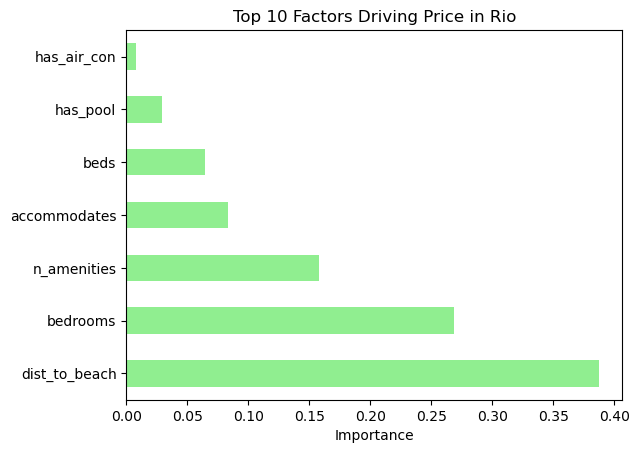

In [6]:
importances = pd.Series(model.feature_importances_, index=features.columns)
importances.nlargest(10).plot(kind='barh', color='lightgreen')
plt.title('Top 10 Factors Driving Price in Rio')
plt.xlabel('Importance')
plt.savefig('feature_importance.png')
plt.show()

In [7]:
# Make sure you use df_clean here!
df_clean['dist_to_beach'] = haversine_distance(
    df_clean['latitude'], df_clean['longitude'],
    IPANEMA_LAT, IPANEMA_LON
)

print("Success! Column 'dist_to_beach' added to df_clean.")

Success! Column 'dist_to_beach' added to df_clean.


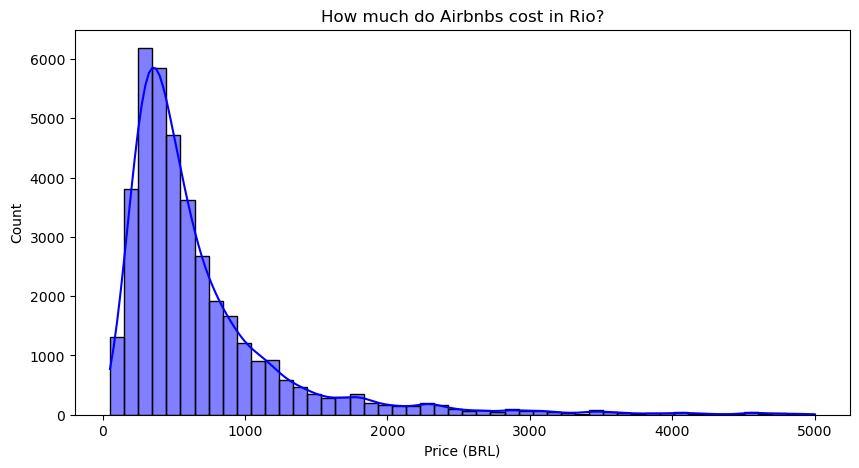

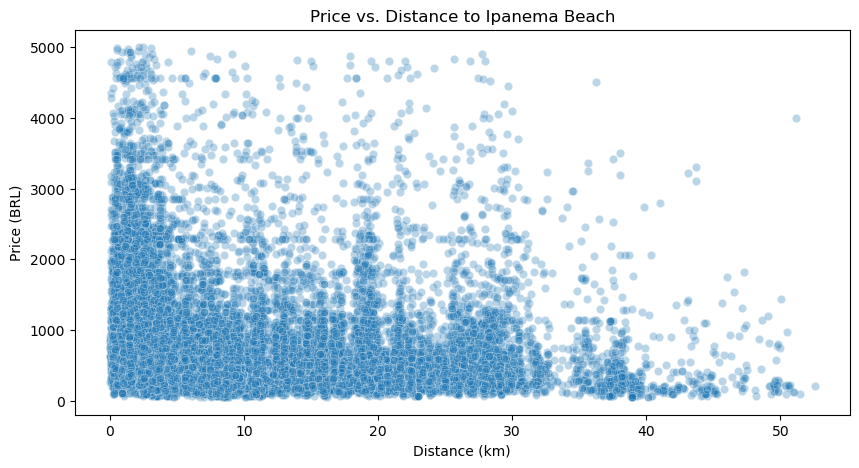

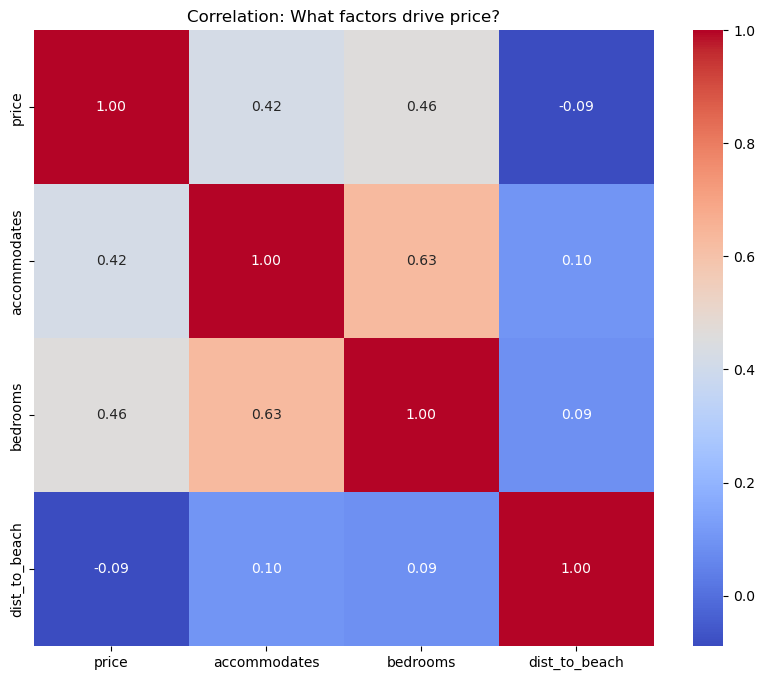

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- EDA 1: Price Distribution ---
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['price'], bins=50, kde=True, color='blue')
plt.title('How much do Airbnbs cost in Rio?')
plt.xlabel('Price (BRL)')
plt.savefig('price_dist.png')
plt.show()

# --- EDA 2: The "Beach" Correlation ---
# Let's see if being close to the beach actually makes it more expensive
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_clean, x='dist_to_beach', y='price', alpha=0.3)
plt.title('Price vs. Distance to Ipanema Beach')
plt.xlabel('Distance (km)')
plt.ylabel('Price (BRL)')
plt.savefig('beach_corr.png')
plt.show()

# --- EDA 3: Feature Correlation Map (Very Professional!) ---
plt.figure(figsize=(10, 8))
# We only look at numbers
corr = df_clean[['price', 'accommodates', 'bedrooms', 'dist_to_beach']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation: What factors drive price?')
plt.savefig('correlation.png')
plt.show()